In [1]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

# =============================================
# FUNGSI DARI PANDUAN
# =============================================

def fungsi_satu(img, batas):
    """
    Thresholding — ubah grayscale jadi biner (hitam putih).
    piksel > batas → 255 (putih)
    piksel <= batas → 0 (hitam)
    Contoh: hasil = fungsi_satu(gray, 127)
    """
    baris, kolom = img.shape
    canvas = np.zeros_like(img, dtype=np.uint8)
    for i in range(baris):
        for j in range(kolom):
            if img[i,j] > batas:
                canvas[i,j] = 255
            elif img[i,j] <= batas:
                canvas[i,j] = 0
    return canvas


def fungsi_dua(image, new_width, new_height):
    """
    Resize — ubah ukuran citra.
    Contoh: hasil = fungsi_dua(citra, 256, 256)
    """
    old_height, old_width = image.shape[:2]
    resized_image = np.zeros((new_height, new_width), dtype=np.uint8)
    for i in range(new_height):
        for j in range(new_width):
            x = int(j * old_width / new_width)
            y = int(i * old_height / new_height)
            resized_image[i, j] = image[y, x]
    return resized_image


def metode_satu(image, kernel):
    """
    Dilasi — perbesar area objek pada citra biner.
    Piksel putih (255) akan meluas sesuai bentuk kernel.
    Contoh: hasil = metode_satu(biner, kernel_cross)
    """
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width))

    for i in range(center, height - center):
        for j in range(center, width - center):
            if image[i, j] == 255:
                for k in range(k_height):
                    for l in range(k_width):
                        if kernel[k, l] == 1:
                            hasil[i+k-center, j+l-center] = 255
            else:
                if hasil[i, j] != 255:
                    hasil[i, j] = 0

    return hasil


def metode_dua(image, kernel):
    """
    Erosi — kurangi/tipiskan area objek pada citra biner.
    Piksel putih hanya dipertahankan kalau semua tetangganya sesuai kernel.
    Contoh: hasil = metode_dua(biner, kernel_cross)
    """
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width), dtype=np.uint8)

    for i in range(center, height - center):
        for j in range(center, width - center):
            cocok = True
            for k in range(k_height):
                for l in range(k_width):
                    if kernel[k, l] == 1 and image[i+k-center, j+l-center] == 0:
                        cocok = False
                        break
                if not cocok:
                    break
            if cocok:
                hasil[i, j] = 255

    return hasil


def metode_tiga(img):
    """
    Thinning — tipiskan objek hingga jadi kerangka (skeleton).
    Menggunakan algoritma Zhang-Suen.
    Contoh: hasil = metode_tiga(biner)
    """
    binary = (img > 0).astype(np.uint8)
    height, width = binary.shape
    changed = True

    while changed:
        changed = False
        hapus = []

        # STEP 1
        for i in range(1, height-1):
            for j in range(1, width-1):
                P1 = binary[i, j]
                if P1 != 1:
                    continue
                P2 = binary[i-1, j]
                P3 = binary[i-1, j+1]
                P4 = binary[i, j+1]
                P5 = binary[i+1, j+1]
                P6 = binary[i+1, j]
                P7 = binary[i+1, j-1]
                P8 = binary[i, j-1]
                P9 = binary[i-1, j-1]
                tetangga = [P2,P3,P4,P5,P6,P7,P8,P9]
                jumlah = np.sum(tetangga)
                transisi = 0
                urutan = tetangga + [P2]
                for k in range(8):
                    if urutan[k] == 0 and urutan[k+1] == 1:
                        transisi += 1
                if (2 <= jumlah <= 6 and transisi == 1 and
                    P2 * P4 * P6 == 0 and P4 * P6 * P8 == 0):
                    hapus.append((i, j))

        if hapus:
            changed = True
            for i, j in hapus:
                binary[i, j] = 0
        hapus = []

        # STEP 2
        for i in range(1, height-1):
            for j in range(1, width-1):
                P1 = binary[i, j]
                if P1 != 1:
                    continue
                P2 = binary[i-1, j]
                P3 = binary[i-1, j+1]
                P4 = binary[i, j+1]
                P5 = binary[i+1, j+1]
                P6 = binary[i+1, j]
                P7 = binary[i+1, j-1]
                P8 = binary[i, j-1]
                P9 = binary[i-1, j-1]
                tetangga = [P2,P3,P4,P5,P6,P7,P8,P9]
                jumlah = np.sum(tetangga)
                transisi = 0
                urutan = tetangga + [P2]
                for k in range(8):
                    if urutan[k] == 0 and urutan[k+1] == 1:
                        transisi += 1
                if (2 <= jumlah <= 6 and transisi == 1 and
                    P2 * P4 * P8 == 0 and P2 * P6 * P8 == 0):
                    hapus.append((i, j))

        if hapus:
            changed = True
            for i, j in hapus:
                binary[i, j] = 0

    return binary * 255


def metode_empat(img, kernel, iterasi=1):
    """
    Thickening — tebalkan objek pada citra biner.
    Dilasi yang diulang sebanyak iterasi.
    Contoh: hasil = metode_empat(biner, kernel_cross, iterasi=3)
    """
    hasil = img.copy()
    for _ in range(iterasi):
        hasil = metode_satu(hasil, kernel)
    return hasil


# =============================================
# KOMBINASI OPERASI MORFOLOGI
# =============================================

def opening(image, kernel):
    """
    Opening = Erosi → Dilasi
    Menghilangkan noise kecil (titik putih kecil di background).
    Contoh: hasil = opening(biner, kernel_cross)
    """
    return metode_satu(metode_dua(image, kernel), kernel)


def closing(image, kernel):
    """
    Closing = Dilasi → Erosi
    Menutup lubang kecil di dalam objek.
    Contoh: hasil = closing(biner, kernel_cross)
    """
    return metode_dua(metode_satu(image, kernel), kernel)


# =============================================
# KERNEL
# =============================================

kernel_diamond = np.array([
    [0,0,1,0,0],
    [0,1,1,1,0],
    [1,1,1,1,1],
    [0,1,1,1,0],
    [0,0,1,0,0]
])

kernel_cross = np.array([
    [0,1,0],
    [1,1,1],
    [0,1,0]
])

kernel_x = np.array([
    [1,0,0,0,1],
    [0,1,0,1,0],
    [0,0,1,0,0],
    [0,1,0,1,0],
    [1,0,0,0,1]
], dtype=np.uint8)

print('✅ Semua fungsi Modul 4 berhasil didefinisikan!')

✅ Semua fungsi Modul 4 berhasil didefinisikan!


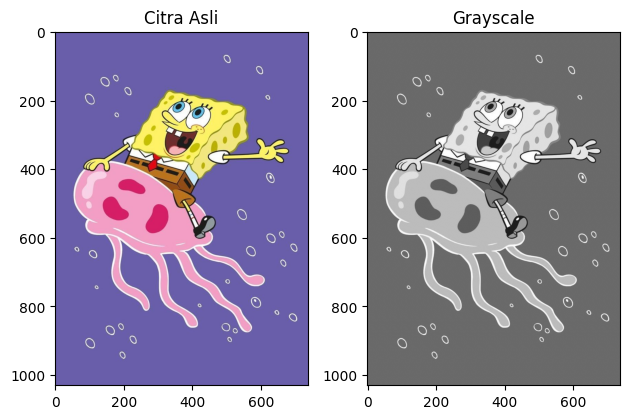

Ukuran: (1030, 736)


In [7]:
# =============================================
# A. PERSIAPAN CITRA
# =============================================

citra = plt.imread('Assets/spongebob-ubur2.jpg')

# Grayscale
gray = cv.cvtColor(citra, cv.COLOR_RGB2GRAY)

plt.subplot(1, 2, 1)
plt.imshow(citra)
plt.title('Citra Asli')

plt.subplot(1, 2, 2)
plt.imshow(gray, cmap='gray')
plt.title('Grayscale')

plt.tight_layout()
plt.show()

print(f"Ukuran: {gray.shape}")

## A. Persiapan Citra

> Citra awal berupa gambar Spongebob yang sedang menunggangi ubur-ubur dengan latar belakang warna ungu dan gelembung-gelembung di sekitarnya. Citra kemudian dikonversi ke grayscale menggunakan `cv.cvtColor()` dengan rumus berbobot `0.299R + 0.587G + 0.114B`, sehingga setiap piksel hanya punya satu nilai intensitas. Hasilnya warna ungu latar belakang, warna kuning Spongebob, dan warna ubur-ubur akan berubah jadi variasi abu-abu sesuai kecerahan warna aslinya.

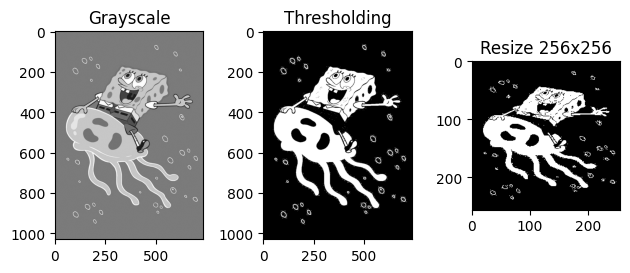

In [3]:
# =============================================
# B. CITRA LATAR — THRESHOLDING + RESIZE
# =============================================

# Thresholding → coba-coba angkanya
biner = fungsi_satu(gray, 127)

# Resize ke 256x256
biner_resize = fungsi_dua(biner, 256, 256)

plt.subplot(1, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title('Grayscale')

plt.subplot(1, 3, 2)
plt.imshow(biner, cmap='gray')
plt.title('Thresholding')

plt.subplot(1, 3, 3)
plt.imshow(biner_resize, cmap='gray')
plt.title('Resize 256x256')

plt.tight_layout()
plt.show()

## B. Citra Latar — Thresholding & Resize

> Thresholding diterapkan ke citra grayscale untuk memisahkan objek (Spongebob + ubur-ubur) dari latar belakang. Piksel yang nilainya di atas batas threshold akan jadi putih (255), sisanya jadi hitam (0). Karena latar belakang ungu punya intensitas tertentu di grayscale, threshold yang tepat akan membantu memisahkan area objek dari latar. Makin besar nilai threshold, makin banyak area yang jadi hitam — makin kecil, makin banyak yang jadi putih. Setelah itu citra di-resize ke 256×256 piksel menggunakan `fungsi_dua()` agar ukurannya seragam dan proses morfologi lebih ringan secara komputasi.

## C. Kernel

> Kernel adalah matriks kecil yang digeser ke seluruh bagian citra untuk menentukan piksel mana yang terpengaruh saat operasi morfologi diterapkan. Tiga kernel yang digunakan memiliki bentuk berbeda:
> - `kernel_cross` (3×3) → berbentuk plus/silang, mempengaruhi 4 arah (atas, bawah, kiri, kanan). Cocok untuk operasi ringan dan cepat.
> - `kernel_diamond` (5×5) → berbentuk belah ketupat, jangkauannya lebih luas dari cross tapi tidak menyentuh sudut. Cocok untuk operasi yang lebih halus.
> - `kernel_x` (5×5) → berbentuk diagonal X, hanya mempengaruhi arah diagonal. Menghasilkan efek yang berbeda dari cross dan diamond.
> Pemilihan kernel mempengaruhi seberapa besar dan ke arah mana objek meluas (dilasi) atau menyusut (erosi).

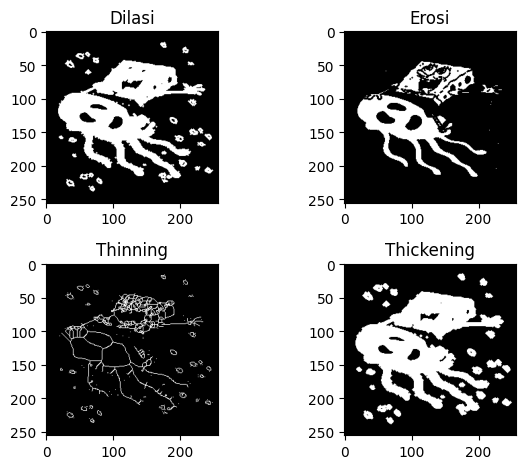

In [4]:
# =============================================
# D. OPERASI MORFOLOGI
# =============================================

# Dilasi
hasil_dilasi = metode_satu(biner_resize, kernel_cross)

# Erosi
hasil_erosi = metode_dua(biner_resize, kernel_cross)

# Thinning
hasil_thinning = metode_tiga(biner_resize)

# Thickening
hasil_thickening = metode_empat(biner_resize, kernel_cross, iterasi=2)

plt.subplot(2, 2, 1)
plt.imshow(hasil_dilasi, cmap='gray')
plt.title('Dilasi')

plt.subplot(2, 2, 2)
plt.imshow(hasil_erosi, cmap='gray')
plt.title('Erosi')

plt.subplot(2, 2, 3)
plt.imshow(hasil_thinning, cmap='gray')
plt.title('Thinning')

plt.subplot(2, 2, 4)
plt.imshow(hasil_thickening, cmap='gray')
plt.title('Thickening')

plt.tight_layout()
plt.show()

## D. Operasi Morfologi

> Empat operasi morfologi diterapkan ke citra biner hasil thresholding:
> - **Dilasi** (`metode_satu`) → area putih (objek Spongebob) meluas sesuai bentuk kernel. Gelembung-gelembung kecil yang tadinya terpisah bisa menyatu, dan kontur objek jadi lebih tebal.
> - **Erosi** (`metode_dua`) → area putih menyusut. Noise kecil dan gelembung tipis akan hilang, objek utama jadi lebih bersih tapi ukurannya mengecil.
> - **Thinning** (`metode_tiga`) → objek ditipiskan sampai mendekati bentuk kerangka/skeleton menggunakan algoritma Zhang-Suen. Hasilnya cuma garis tipis yang merepresentasikan bentuk Spongebob dan ubur-ubur.
> - **Thickening** (`metode_empat`) → kebalikan thinning, objek dipertebal dengan mengulangi dilasi beberapa kali sesuai parameter iterasi.

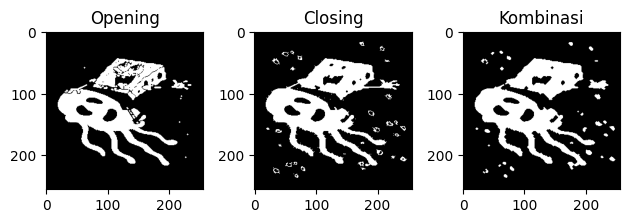

In [5]:
# =============================================
# E. KOMBINASI OPERASI
# =============================================

# Opening = Erosi → Dilasi (hilangkan noise)
hasil_opening = opening(biner_resize, kernel_cross)

# Closing = Dilasi → Erosi (tutup lubang)
hasil_closing = closing(biner_resize, kernel_cross)

# Kombinasi lain — coba-coba
hasil_kombinasi = opening(closing(biner_resize, kernel_diamond), kernel_cross)

plt.subplot(1, 3, 1)
plt.imshow(hasil_opening, cmap='gray')
plt.title('Opening')

plt.subplot(1, 3, 2)
plt.imshow(hasil_closing, cmap='gray')
plt.title('Closing')

plt.subplot(1, 3, 3)
plt.imshow(hasil_kombinasi, cmap='gray')
plt.title('Kombinasi')

plt.tight_layout()
plt.show()

## E. Kombinasi Operasi

> Kombinasi dua operasi morfologi diterapkan untuk mendapatkan hasil yang lebih bersih:
> - **Opening** (Erosi → Dilasi) → menghilangkan noise kecil seperti gelembung-gelembung tipis di sekitar objek tanpa terlalu mengubah bentuk objek utama. Cocok kalau hasil thresholding masih banyak bintik putih di background.
> - **Closing** (Dilasi → Erosi) → menutup lubang-lubang kecil di dalam area objek, membuat area putih jadi lebih solid dan rapat. Cocok kalau objek Spongebob masih punya area hitam di dalamnya.
> - **Kombinasi** (Closing → Opening) → diterapkan untuk mendapatkan hasil terbaik: lubang dalam objek ditutup dulu, baru noise di luar dihilangkan. Hasilnya objek lebih utuh sekaligus background lebih bersih.

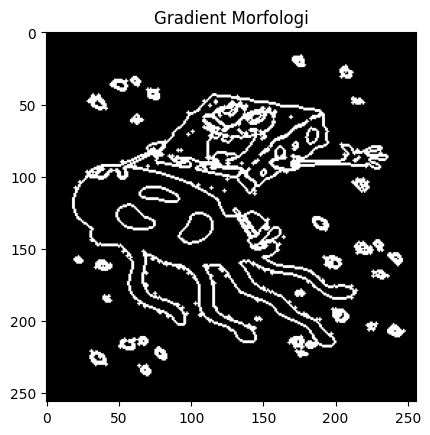

In [6]:
def gradient_morph(image, kernel):
    """
    Gradient Morfologi = Dilasi - Erosi
    Menghasilkan tepi/kontur objek dari citra biner.
    Contoh: hasil = gradient_morph(biner, kernel_cross)
    """
    dilasi = metode_satu(image, kernel)
    erosi  = metode_dua(image, kernel)

    h, w = image.shape
    hasil = np.zeros((h, w), dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            val = int(dilasi[i,j]) - int(erosi[i,j])
            hasil[i,j] = 255 if val > 0 else 0

    return hasil

hasil_gradient = gradient_morph(biner_resize, kernel_cross)

plt.imshow(hasil_gradient, cmap='gray')
plt.title('Gradient Morfologi')
plt.show()

## Gradient Morfologi

> Gradient morfologi dihitung dari selisih dilasi dan erosi (`dilasi - erosi`). Karena dilasi memperluas objek ke luar dan erosi mempersempitnya ke dalam, selisih keduanya hanya menyisakan bagian pinggir/tepi objek. Hasilnya mirip deteksi tepi seperti Sobel, tapi menggunakan operasi morfologi sehingga lebih tahan terhadap noise dibanding konvolusi biasa. Pada gambar Spongebob, hasilnya akan menampilkan kontur luar tubuh Spongebob, ubur-ubur, dan gelembung sebagai garis tipis putih di atas background hitam.